In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("EDA ASSIGNMENT - TITANIC DATASET")
print("=" * 60)

EDA ASSIGNMENT - TITANIC DATASET


In [3]:
try:
    df_raw = pd.read_csv("Titanic-Dataset.csv")
except UnicodeDecodeError:
    df_raw = pd.read_csv("Titanic-Dataset.csv", encoding="latin1")
df = df_raw.copy()

In [4]:
print("PART A: DATA UNDERSTANDING")
print("=" * 60)
print("First 5 rows")
print("-" * 60)
print(df.head())

PART A: DATA UNDERSTANDING
First 5 rows
------------------------------------------------------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      

In [5]:
print("Dataset Information")
print("-" * 60)
df.info()

Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print("Statistical Summary")
print("-" * 60)
print(df.describe())

Statistical Summary
------------------------------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
print("Dataset Shape")
print("-" * 60)
print(df.shape)

Dataset Shape
------------------------------------------------------------
(891, 12)


In [8]:
print("Missing Values Count")
print("-" * 60)
print(df.isnull().sum())

Missing Values Count
------------------------------------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
print("Percentage of Missing Values")
print("-" * 60)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Percentage of Missing Values
------------------------------------------------------------
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [10]:
print("Data Types")
print("-" * 60)
print(df.dtypes)

Data Types
------------------------------------------------------------
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [11]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns
print("Numerical Features")
print("-" * 60)
print(numerical_features)
print("\nCategorical Features")
print("-" * 60)
print(categorical_features)

Numerical Features
------------------------------------------------------------
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Categorical Features
------------------------------------------------------------
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [12]:
print("PART B: DATA CLEANING")
print("=" * 60)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"], errors="ignore")
print("Missing values after cleaning")
print("-" * 60)
print(df.isnull().sum())

PART B: DATA CLEANING
Missing values after cleaning
------------------------------------------------------------
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [13]:
encoded_df = df.copy()
encoded_df = encoded_df.drop(columns=["PassengerId", "Name", "Ticket"], errors="ignore")
encoded_df = pd.get_dummies(encoded_df, columns=["Sex", "Embarked"], drop_first=True)
print("Encoded Dataset")
print("-" * 60)
print(encoded_df.head())
print("\nEncoded Data Types")
print("-" * 60)
print(encoded_df.dtypes)

Encoded Dataset
------------------------------------------------------------
   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500         1           0   
1         1       1  38.0      1      0  71.2833         0           0   
2         1       3  26.0      0      0   7.9250         0           0   
3         1       1  35.0      1      0  53.1000         0           0   
4         0       3  35.0      0      0   8.0500         1           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  

Encoded Data Types
------------------------------------------------------------
Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        uint8
Embarked_Q      uint8
Embarked_S      uint8
dtype: object


In [14]:
print("PART C: UNIVARIATE ANALYSIS")
print("=" * 60)

PART C: UNIVARIATE ANALYSIS


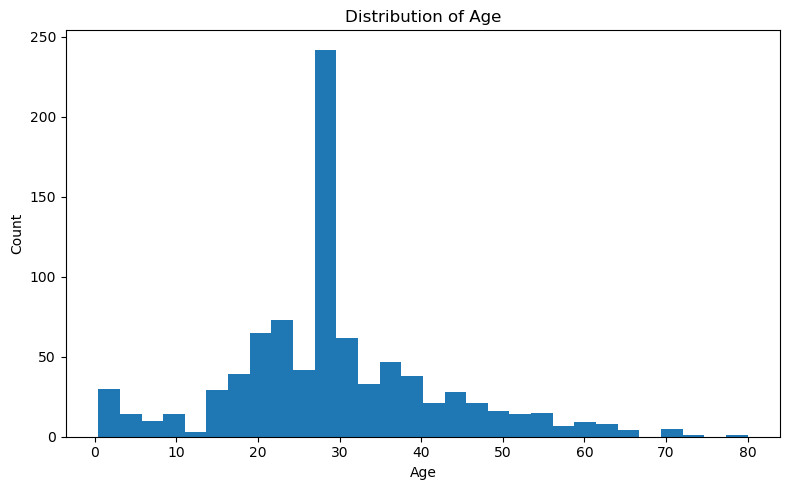

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age")
plt.tight_layout()
plt.show()

Count of Passengers by Sex
------------------------------------------------------------
male      577
female    314
Name: Sex, dtype: int64


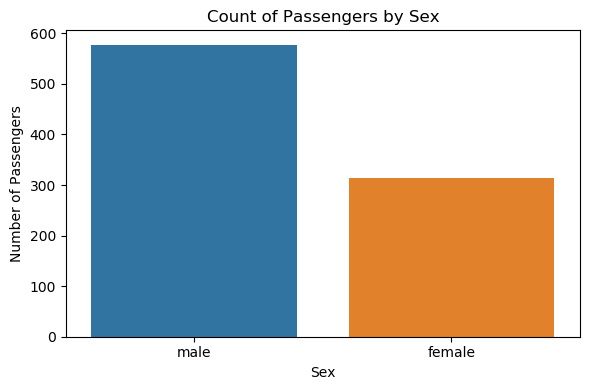

In [16]:
print("Count of Passengers by Sex")
print("-" * 60)
print(df["Sex"].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", data=df)
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.title("Count of Passengers by Sex")
plt.tight_layout()
plt.show()

Count of Passengers by Pclass
------------------------------------------------------------
1    216
2    184
3    491
Name: Pclass, dtype: int64


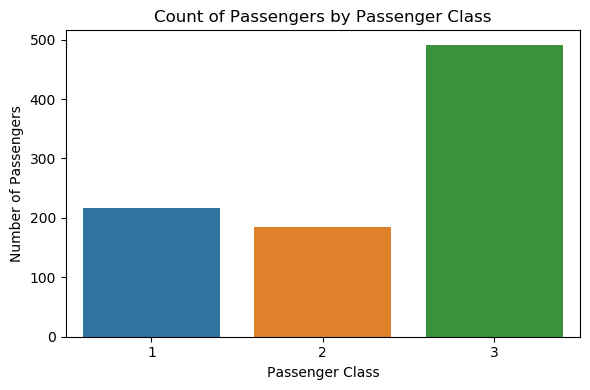

In [17]:
print("Count of Passengers by Pclass")
print("-" * 60)
print(df["Pclass"].value_counts().sort_index())
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", data=df)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Count of Passengers by Passenger Class")
plt.tight_layout()
plt.show()

Survival Rate
------------------------------------------------------------
0    61.616162
1    38.383838
Name: Survived, dtype: float64


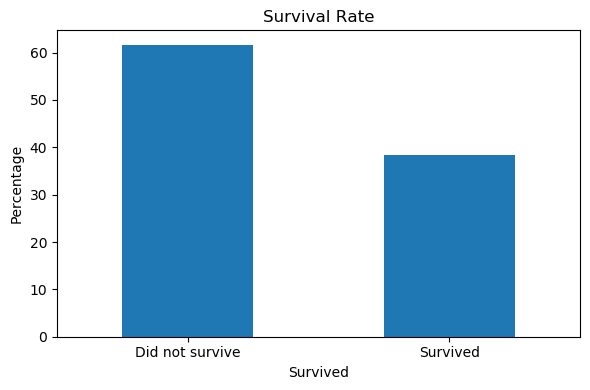

In [18]:
survival_rate = df["Survived"].value_counts(normalize=True).sort_index() * 100
print("Survival Rate")
print("-" * 60)
print(survival_rate)
plt.figure(figsize=(6, 4))
survival_rate.plot(kind="bar")
plt.xlabel("Survived")
plt.ylabel("Percentage")
plt.title("Survival Rate")
plt.xticks(ticks=[0, 1], labels=["Did not survive", "Survived"], rotation=0)
plt.tight_layout()
plt.show()

In [19]:
print("PART D: BIVARIATE ANALYSIS")
print("=" * 60)

PART D: BIVARIATE ANALYSIS


Survival Rate by Sex
------------------------------------------------------------
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


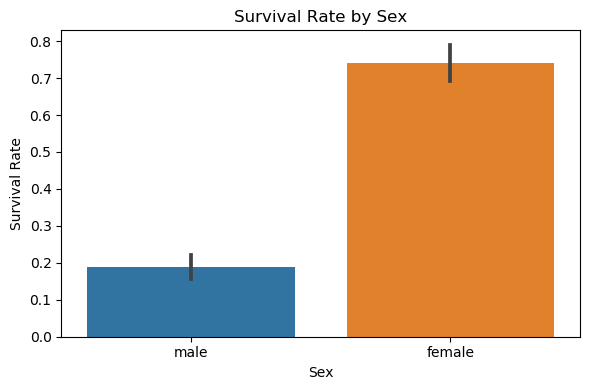

In [22]:
sex_survival = df.groupby("Sex")["Survived"].mean() * 100
print("Survival Rate by Sex")
print("-" * 60)
print(sex_survival)
plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df)
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")
plt.tight_layout()
plt.show()

In [ ]:
pclass_survival = df.groupby("Pclass")["Survived"].mean() * 100
print("Survival Rate by Pclass")
print("-" * 60)
print(pclass_survival)
plt.figure(figsize=(6, 4))
sns.barplot(x="Pclass", y="Survived", data=df)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.tight_layout()
plt.show()

In [ ]:
age_survival = df.groupby("Survived")["Age"].mean()
print("Average Age of Survivors vs Non-Survivors")
print("-" * 60)
print(age_survival)
plt.figure(figsize=(6, 4))
sns.barplot(x="Survived", y="Age", data=df)
plt.xlabel("Survived")
plt.ylabel("Average Age")
plt.title("Average Age of Survivors vs Non-Survivors")
plt.xticks(ticks=[0, 1], labels=["Did not survive", "Survived"])
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Survived", y="Fare", data=df)
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Fare Distribution by Survival")
plt.xticks(ticks=[0, 1], labels=["Did not survive", "Survived"])
plt.tight_layout()
plt.show()

In [ ]:
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100
print("Survival Rate by Embarked Port")
print("-" * 60)
print(embarked_survival)
plt.figure(figsize=(6, 4))
sns.barplot(x="Embarked", y="Survived", data=df)
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Embarked Port")
plt.tight_layout()
plt.show()

In [ ]:
print("PART E: MULTIVARIATE ANALYSIS")
print("=" * 60)

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate across Sex and Pclass")
plt.tight_layout()
plt.show()

In [ ]:
sex_pclass_table = df.pivot_table(
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
) * 100

print("Survival Rate across Sex and Pclass")
print("-" * 60)
print(sex_pclass_table)
plt.figure(figsize=(7, 4))
sns.heatmap(sex_pclass_table, annot=True, fmt=".2f")
plt.xlabel("Passenger Class")
plt.ylabel("Sex")
plt.title("Survival Rate Heatmap: Sex and Pclass")
plt.tight_layout()
plt.show()

In [ ]:
sex_pclass_embarked = df.groupby(["Sex", "Pclass", "Embarked"])["Survived"].mean() * 100
print("Survival Rate across Sex, Pclass, and Embarked")
print("-" * 60)
print(sex_pclass_embarked)

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Pclass", y="Survived", hue="Embarked", data=df)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate across Pclass and Embarked")
plt.tight_layout()
plt.show()

In [ ]:
numeric_data = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
correlation_table = numeric_data.corr()
print("Correlation Table")
print("-" * 60)
print(correlation_table)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_table, annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()